<a href="https://colab.research.google.com/github/monikabenavides/MaestriaUHE/blob/main/Actividad1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Portada del Notebook

**Nombre del Estudiante:** Mónica Benavides

**Módulo:** Big Data, Analyst & Data Scientist

**Docente:** Carlos Wladimir Carrillo Villavicencio

**Tema del Análisis:** Análisis de Datos de IRAG Fallecidos

**Fecha:** 26/06/2026

# Índice del Notebook

- [Introducción](#Introducción)
- [Carga y Exploración Inicial de Datos](#Carga-y-Exploración-Inicial-de-Datos)
- [Limpieza de Datos](#Limpieza-de-Datos)
- [Análisis Exploratorio de Datos (EDA)](#Análisis-Exploratorio-de-Datos-(EDA))
- [Visualización de Datos](#Visualización-de-Datos)
- [Machine Learning (ML)](#Machine-Learning-(ML))
- [Conclusiones](#Conclusiones)

# Introducción


### Descripción del Dataset
Este dataset contiene información sobre casos de Infección Respiratoria Aguda Grave (IRAG) fallecidos, proporcionando detalles demográficos, clínicos y de laboratorio de los pacientes. El objetivo principal de este análisis es comprender los factores asociados a la mortalidad por IRAG y extraer insights que puedan ayudar en la prevención y el manejo de futuros casos.

### Fuente
El archivo `irag_fallecidos.csv` ha sido cargado desde la ruta `/content/drive/MyDrive/Task1/irag_fallecidos.csv`.

### Variable Objetivo
Para este análisis, la variable objetivo podría ser determinada basándose en el campo `fallecido_si_no`. Identificaremos las columnas relevantes para predecir si un paciente fallece debido a IRAG.

# Carga y Exploración Inicial de Datos

In [10]:
import pandas as pd
import hashlib

In [11]:
# Cargar el archivo especificando el separador correcto
df = pd.read_csv('/content/drive/MyDrive/Task1/irag_fallecidos.csv', sep=';')
# Eliminar posibles espacios en blanco en los nombres de las columnas
df.columns = df.columns.str.strip()

In [14]:
print('### Primeras 5 filas del Dataset')
display(df.head())

### Primeras 5 filas del Dataset


,cod_paciente,fecha_caso_pac,unidad_operativa,tipo_atencion,fecha_hospitalizacion,nacionalidad,provincia,canton,sexo_pac,edad_pac,...,egreso_uci,confirmado_por,fecha_cierre,tipo_muestra_laboratorio,fecha_toma_laboratorio,fecha_recepcion_laboratorio,muestra_adecuada,fecha_muestra_procesada,resultado_laboratorio,agente_epidemiologico
0,58297,8/11/2023,HOSPITAL DE NIÃ‘OS BACA ORTIZ,hosptalizacion,7/11/2023,Ecuador,Sucumbios,Shushufindi,Femenino,1,...,8/11/2023,Laboratorio,10/11/2023,Hisopado Nasofar?ngeo,8/11/2023,8/11/2023,Si,8/11/2023,Negativo,Negativo
1,46486,26/1/2022,HOSPITAL DE NIÃ‘OS BACA ORTIZ,hosptalizacion,26/1/2022,Ecuador,Sucumbios,Lago Agrio,Femenino,1,...,27/1/2022,Laboratorio,2/2/2022,Hisopado Nasofar?ngeo,27/1/2022,28/1/2022,Si,28/1/2022,Positivo,SARS CoV2
2,54041,23/3/2023,HOSPITAL DE NIÃ‘OS BACA ORTIZ,hosptalizacion,22/3/2023,Ecuador,Sucumbios,Nueva Loja,Femenino,9,...,26/3/2023,Laboratorio,28/3/2023,Hisopado Nasofar?ngeo,23/3/2023,24/3/2023,Si,24/3/2023,Negativo,Negativo
3,53467,7/3/2023,HOSPITAL VICENTE CORRAL MOSCOSO,hosptalizacion,7/3/2023,Ecuador,Zamora Chinchipe,ZAMORA,Femenino,7,...,9/3/2023,Laboratorio,10/3/2023,Hisopado Nasofar?ngeo,7/3/2023,8/3/2023,Si,8/3/2023,Positivo,Influenza B
4,50084,3/10/2022,HOSPITAL VICENTE CORRAL MOSCOSO,hosptalizacion,3/10/2022,Ecuador,Morona Santiago,GUALAQUIZA EL PANGUI,Femenino,3,...,17/10/2022,Laboratorio,18/10/2022,Hisopado Nasofar?ngeo,3/10/2022,4/10/2022,Si,4/10/2022,Negativo,Negativo


In [42]:
print('### Tamaño del Dataset')
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.\n")

print('### Variables y Tipos de Datos')
df.info()

### Tamaño del Dataset
El dataset tiene 1584 filas y 32 columnas.

### Variables y Tipos de Datos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1584 entries, 0 to 1583
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   cod_paciente                 1584 non-null   int64         
 1   fecha_caso_pac               1584 non-null   datetime64[ns]
 2   unidad_operativa             1584 non-null   object        
 3   tipo_atencion                1584 non-null   object        
 4   fecha_hospitalizacion        1584 non-null   datetime64[ns]
 5   nacionalidad                 1584 non-null   object        
 6   provincia                    1584 non-null   object        
 7   canton                       1584 non-null   object        
 8   sexo_pac                     1584 non-null   object        
 9   edad_pac                     1584 non-null   int64         
 10  tipo_edad_

# Limpieza de Datos

In [40]:
import pandas as pd

# 1. Corrección de caracteres especiales (Sustituir '?' por 'Ñ')
df = df.replace('\\?', 'Ñ', regex=True)

# 2. Homologación de edad
def homologar_edad(row):
    edad = row['edad_pac']
    tipo = str(row['tipo_edad_pac']).upper()
    if 'MES' in tipo:
        return edad / 12
    elif 'DIA' in tipo:
        return edad / 365
    return edad

df['edad_homologada'] = df.apply(homologar_edad, axis=1)

# 3. Estandarización de texto (MAYÚSCULAS y sin espacios)
columnas_obj = df.select_dtypes(include=['object']).columns
for col in columnas_obj:
    df[col] = df[col].astype(str).str.upper().str.strip()

# 4. Manejo de valores nulos en columnas críticas
df['embarazo'] = df['embarazo'].fillna('NO APLICA')
df['ingreso_uci'] = df['ingreso_uci'].fillna('NO')
df['egreso_uci'] = df['egreso_uci'].fillna('NO')

print("Limpieza completada: '?' reemplazado por 'Ñ', edad homologada y todos los textos en MAYÚSCULAS.")
print(f"El dataset tiene actualmente {df.shape[0]} filas y {df.shape[1]} columnas.")

print("\n--- Primeras 5 filas ---")
display(df[['edad_pac', 'tipo_edad_pac', 'edad_homologada', 'sexo_pac', 'comorbilidad']].head())

print("\n--- Últimas 5 filas ---")
display(df[['edad_pac', 'tipo_edad_pac', 'edad_homologada', 'sexo_pac', 'comorbilidad']].tail())


Limpieza completada: '?' reemplazado por 'Ñ', edad homologada y todos los textos en MAYÚSCULAS.
El dataset tiene actualmente 1584 filas y 32 columnas.

--- Primeras 5 filas ---


,edad_pac,tipo_edad_pac,edad_homologada,sexo_pac,comorbilidad
0,1,AÑOS,1.000000,FEMENINO,SI
1,1,AÑOS,1.000000,FEMENINO,NO
2,9,AÑOS,9.000000,FEMENINO,NO
3,7,MESES,0.583333,FEMENINO,NO
4,3,MESES,0.250000,FEMENINO,NO



--- Últimas 5 filas ---


,edad_pac,tipo_edad_pac,edad_homologada,sexo_pac,comorbilidad
1579,15,AÑOS,15.000000,FEMENINO,SI
1580,4,MESES,0.333333,MASCULINO,NO
1581,5,MESES,0.416667,MASCULINO,SI
1582,80,AÑOS,80.000000,FEMENINO,NO
1583,8,MESES,0.666667,MASCULINO,SI


# Análisis Exploratorio de Datos (EDA)

### Estadística Descriptiva de Variables Numéricas


,cod_paciente,fecha_caso_pac,fecha_hospitalizacion,edad_pac,semana_epi,fecha_investigacion,fecha_fallecimiento,fecha_cierre,fecha_toma_laboratorio,fecha_recepcion_laboratorio,fecha_muestra_procesada,edad_homologada
count,1584.000000,1584,1584,1584.000000,1584.000000,1584,1322,1584,1584,1584,1584,1584.000000
mean,47669.800505,2022-01-29 09:13:38.181818112,2022-01-28 02:13:38.181818368,52.893308,21.098485,2022-01-29 09:13:38.181818112,2021-12-29 00:07:37.488653568,2022-03-01 18:42:43.636363520,2022-01-29 15:37:16.363636224,2022-01-30 16:31:49.090908928,2022-01-31 07:00:54.545454592,52.436711
min,40960.000000,2021-01-01 00:00:00,2020-12-31 00:00:00,1.000000,1.000000,2021-01-01 00:00:00,2021-01-03 00:00:00,2021-01-06 00:00:00,2021-01-01 00:00:00,2021-01-02 00:00:00,2021-01-02 00:00:00,0.083333
25%,43598.500000,2021-04-13 00:00:00,2021-04-11 00:00:00,34.000000,11.000000,2021-04-13 00:00:00,2021-04-16 00:00:00,2021-05-09 00:00:00,2021-04-13 18:00:00,2021-04-14 00:00:00,2021-04-14 18:00:00,34.000000
50%,45477.000000,2021-08-12 12:00:00,2021-08-11 00:00:00,61.000000,17.500000,2021-08-12 12:00:00,2021-07-16 00:00:00,2021-09-28 00:00:00,2021-08-12 12:00:00,2021-08-14 12:00:00,2021-08-16 00:00:00,61.000000
75%,51183.000000,2022-12-10 12:00:00,2022-12-07 18:00:00,76.000000,29.000000,2022-12-10 12:00:00,2022-09-23 12:00:00,2022-12-28 06:00:00,2022-12-10 12:00:00,2022-12-12 00:00:00,2022-12-13 00:00:00,76.000000
max,59769.000000,2023-12-29 00:00:00,2023-12-29 00:00:00,103.000000,53.000000,2023-12-29 00:00:00,2023-10-10 00:00:00,2024-01-22 00:00:00,2023-12-30 00:00:00,2024-01-02 00:00:00,2024-01-02 00:00:00,103.000000
std,5130.379870,NaN,NaN,28.879025,14.092929,NaN,NaN,NaN,NaN,NaN,NaN,29.646871



### Distribución de Variables Categóricas Principales


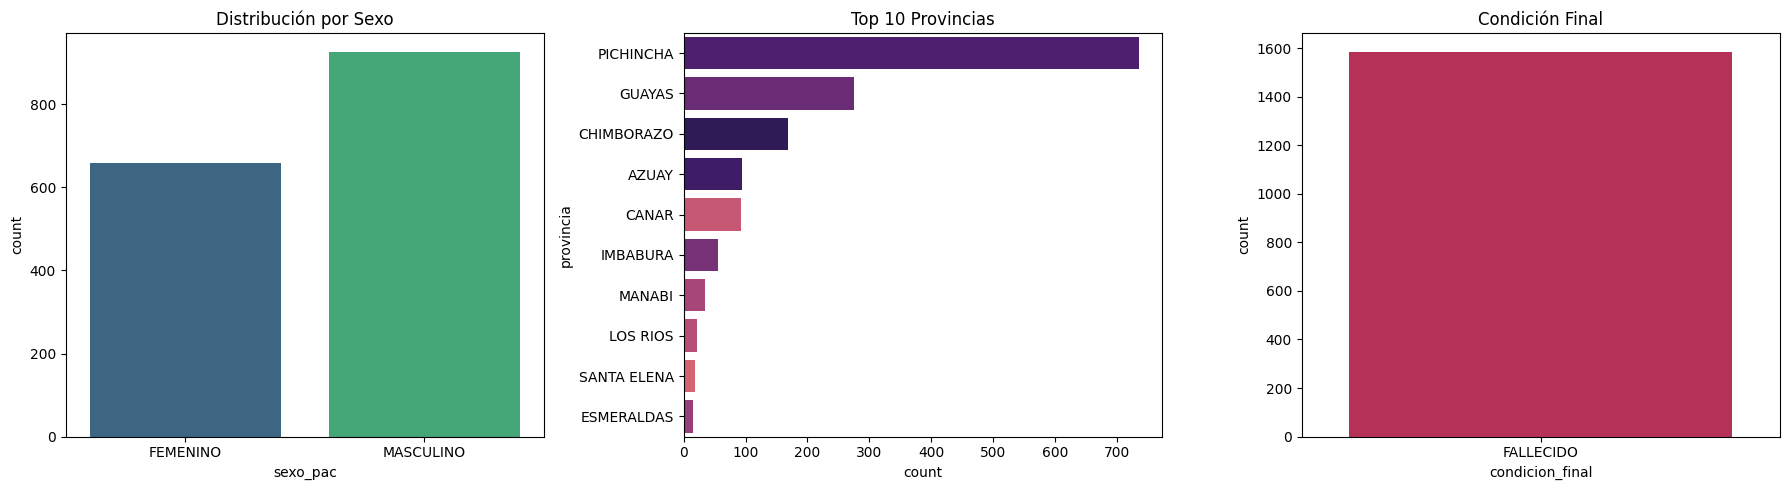


### Evolución Temporal de Casos


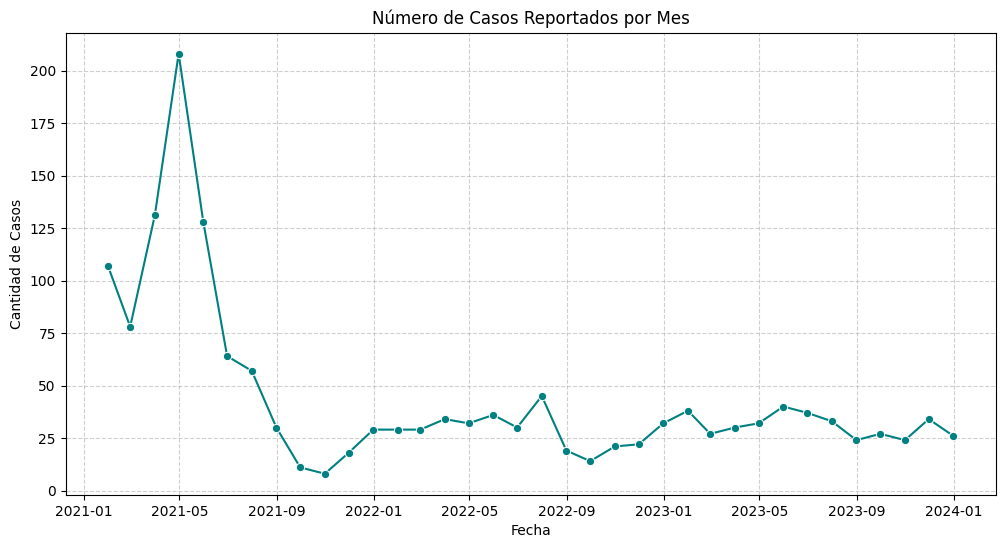

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Estadística Descriptiva
print("### Estadística Descriptiva de Variables Numéricas")
display(df.describe())

# 2. Análisis de Variables Categóricas
print("\n### Distribución de Variables Categóricas Principales")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='sexo_pac', ax=axes[0], palette='viridis', hue='sexo_pac', legend=False)
axes[0].set_title('Distribución por Sexo')

sns.countplot(data=df, y='provincia', ax=axes[1], palette='magma', order=df['provincia'].value_counts().index[:10], hue='provincia', legend=False)
axes[1].set_title('Top 10 Provincias')

sns.countplot(data=df, x='condicion_final', ax=axes[2], palette='rocket', hue='condicion_final', legend=False)
axes[2].set_title('Condición Final')

plt.tight_layout()
plt.show()

# 3. Análisis de Variables Temporales
print("\n### Evolución Temporal de Casos")
# Se cambia 'M' por 'ME' para evitar FutureWarning en pandas
df_temp = df.set_index(pd.to_datetime(df['fecha_caso_pac'])).resample('ME').size().reset_index(name='conteo')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_temp, x='fecha_caso_pac', y='conteo', marker='o', color='teal')
plt.title('Número de Casos Reportados por Mes')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Casos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

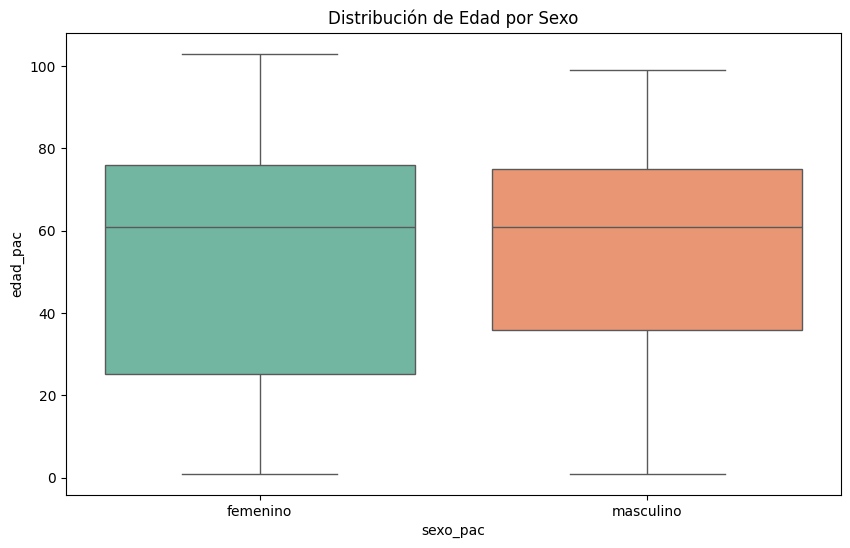

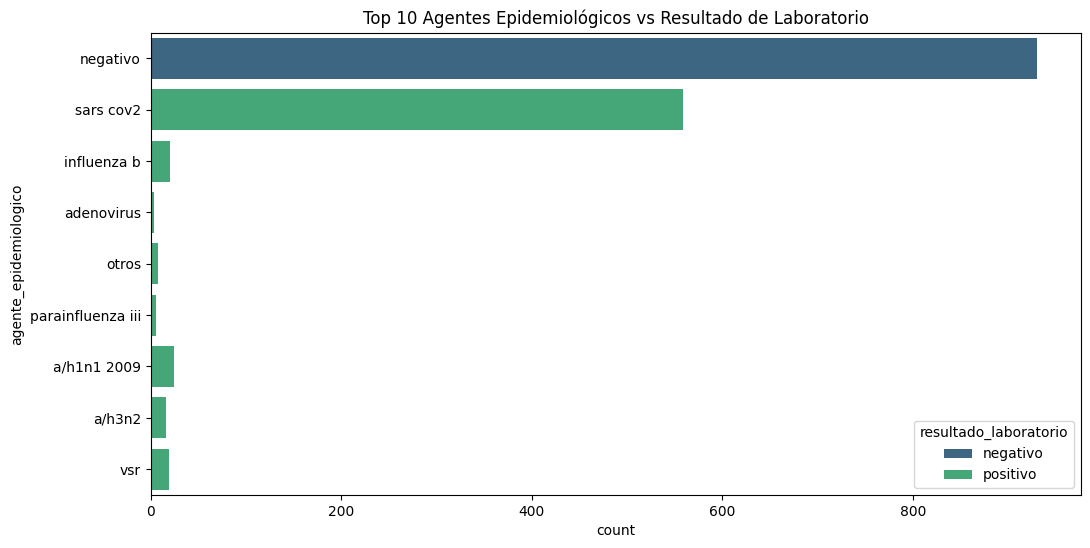

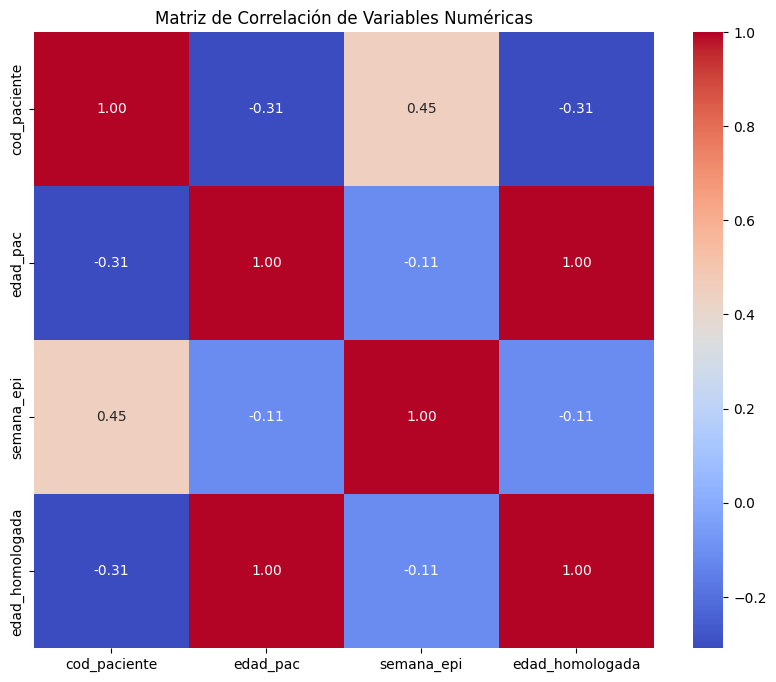

In [30]:
import plotly.express as px

# 1. Distribución de Edad por Sexo (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sexo_pac', y='edad_pac', palette='Set2', hue='sexo_pac', legend=False)
plt.title('Distribución de Edad por Sexo')
plt.show()

# 2. Resultados de Laboratorio por Agente Epidemiológico
plt.figure(figsize=(12, 6))
top_agentes = df['agente_epidemiologico'].value_counts().nlargest(10).index
sns.countplot(data=df[df['agente_epidemiologico'].isin(top_agentes)],
              y='agente_epidemiologico', hue='resultado_laboratorio', palette='viridis')
plt.title('Top 10 Agentes Epidemiológicos vs Resultado de Laboratorio')
plt.show()

# 3. Heatmap de correlación (Variables numéricas)
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

# Visualización de Datos

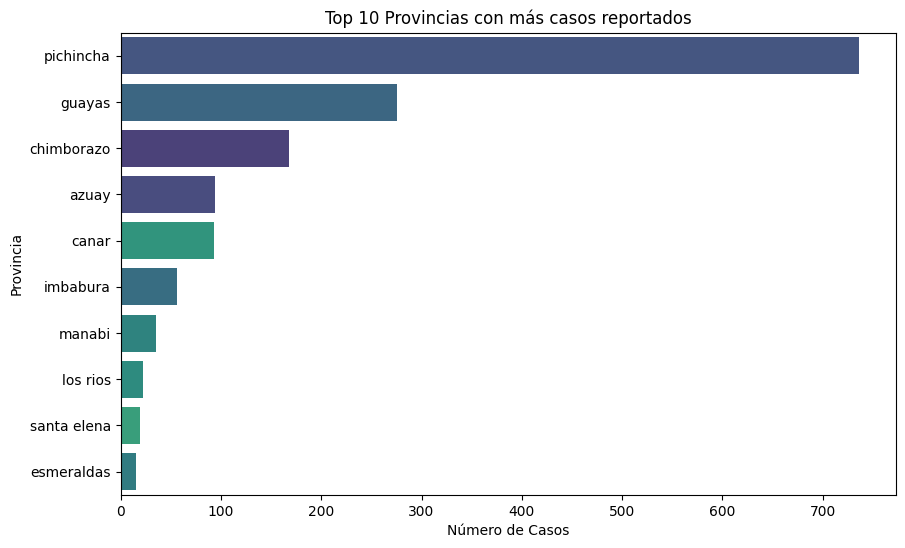

Explicación: Este gráfico muestra que la gran mayoría de los casos reportados se concentran en Pichincha y Guayas, lo cual es consistente con la densidad poblacional de estas regiones.


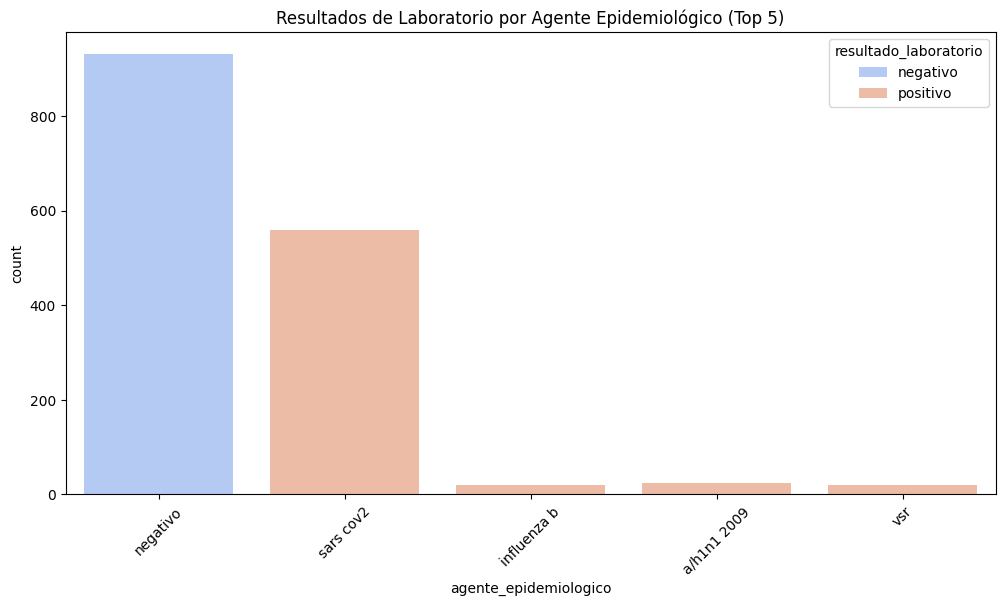

Explicación: Podemos observar que 'sars cov2' es el agente positivo más frecuente, mientras que una gran parte de las muestras resultan 'negativo' o indeterminadas.


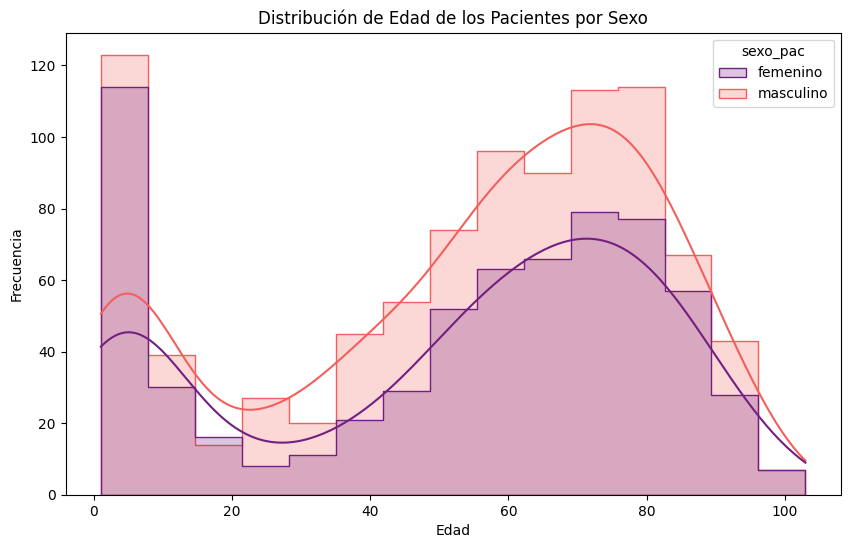

Explicación: La distribución muestra que la mayoría de los casos ocurren en adultos mayores (pico entre 60 y 80 años), con una distribución similar entre hombres y mujeres, aunque con una ligera predominancia masculina en ciertos rangos.


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribución por Provincias (Top 10)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='provincia', order=df['provincia'].value_counts().iloc[:10].index, hue='provincia', palette='viridis', legend=False)
plt.title('Top 10 Provincias con más casos reportados')
plt.xlabel('Número de Casos')
plt.ylabel('Provincia')
plt.show()
print("Explicación: Este gráfico muestra que la gran mayoría de los casos reportados se concentran en Pichincha y Guayas, lo cual es consistente con la densidad poblacional de estas regiones.")

# 2. Relación entre Agente Epidemiológico y Resultado
plt.figure(figsize=(12, 6))
top_agentes = df['agente_epidemiologico'].value_counts().nlargest(5).index
sns.countplot(data=df[df['agente_epidemiologico'].isin(top_agentes)],
              x='agente_epidemiologico', hue='resultado_laboratorio', palette='coolwarm')
plt.title('Resultados de Laboratorio por Agente Epidemiológico (Top 5)')
plt.xticks(rotation=45)
plt.show()
print("Explicación: Podemos observar que 'sars cov2' es el agente positivo más frecuente, mientras que una gran parte de las muestras resultan 'negativo' o indeterminadas.")

# 3. Distribución de Edad por Sexo
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='edad_pac', hue='sexo_pac', kde=True, element='step', palette='magma')
plt.title('Distribución de Edad de los Pacientes por Sexo')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()
print("Explicación: La distribución muestra que la mayoría de los casos ocurren en adultos mayores (pico entre 60 y 80 años), con una distribución similar entre hombres y mujeres, aunque con una ligera predominancia masculina en ciertos rangos.")

# Machine Learning (ML)

### Reporte de Clasificación (Datos Limpios y en MAYÚSCULAS)
              precision    recall  f1-score   support

          NO       0.58      0.45      0.51       148
          SI       0.60      0.72      0.65       169

    accuracy                           0.59       317
   macro avg       0.59      0.58      0.58       317
weighted avg       0.59      0.59      0.59       317



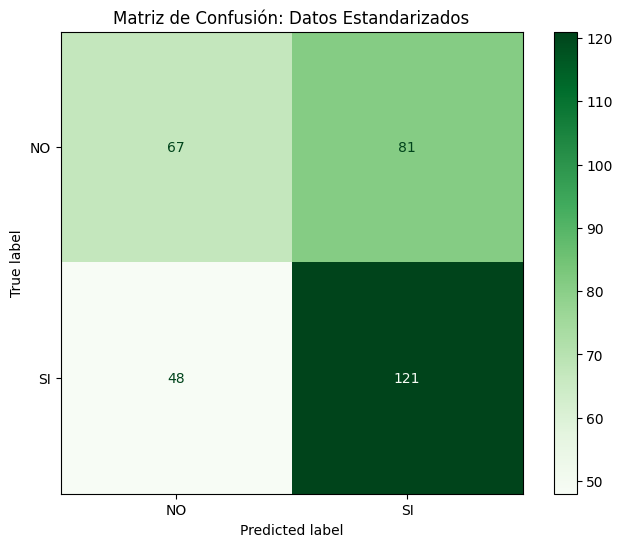

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Preparación de datos con el dataset limpio
features = ['edad_homologada', 'provincia', 'sexo_pac']
target = 'comorbilidad'

# Creamos una copia para el modelo
ml_df = df[features + [target]].dropna().copy()

# Codificación de variables (ahora sobre etiquetas en MAYÚSCULAS)
le_prov = LabelEncoder()
ml_df['provincia'] = le_prov.fit_transform(ml_df['provincia'].astype(str))

le_sex = LabelEncoder()
ml_df['sexo_pac'] = le_sex.fit_transform(ml_df['sexo_pac'].astype(str))

le_target = LabelEncoder()
ml_df[target] = le_target.fit_transform(ml_df[target].astype(str))

# 2. División train_test_split
X = ml_df.drop(target, axis=1)
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenamiento del modelo base con datos limpios
model_comorb = RandomForestClassifier(n_estimators=100, random_state=42)
model_comorb.fit(X_train, y_train)

# 4. Evaluación
y_pred = model_comorb.predict(X_test)

print("### Reporte de Clasificación (Datos Limpios y en MAYÚSCULAS)")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Matriz de Confusión
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_).plot(cmap='Greens', ax=ax)
plt.title('Matriz de Confusión: Datos Estandarizados')
plt.show()

Iniciando optimización final con datos en MAYÚSCULAS...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Mejores parámetros encontrados: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}

### Reporte de Clasificación (Modelo Optimizado Final)
              precision    recall  f1-score   support

          NO       0.63      0.31      0.42       148
          SI       0.58      0.84      0.69       169

    accuracy                           0.59       317
   macro avg       0.61      0.58      0.55       317
weighted avg       0.60      0.59      0.56       317



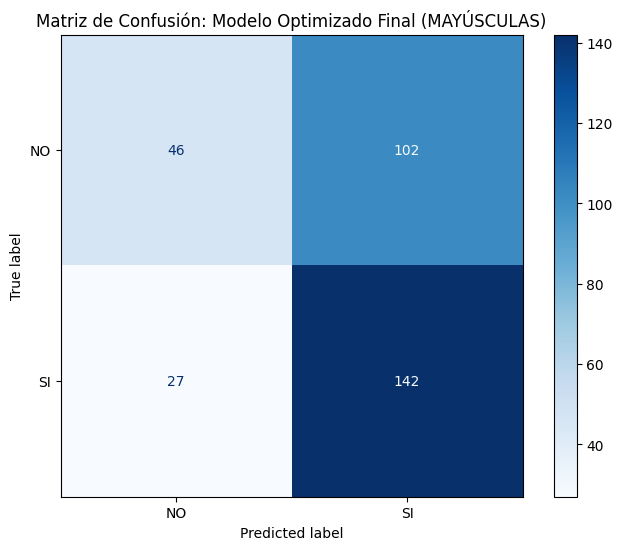

In [38]:
from sklearn.model_selection import GridSearchCV

# 1. Definir la rejilla de parámetros sobre los datos en MAYÚSCULAS
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 2. Configurar GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=1, scoring='accuracy')

# 3. Entrenar con la búsqueda de hiperparámetros y etiquetas estandarizadas
print("Iniciando optimización final con datos en MAYÚSCULAS...")
grid_search.fit(X_train, y_train)

# 4. Mejores parámetros y evaluación
best_model = grid_search.best_estimator_
print(f"\nMejores parámetros encontrados: {grid_search.best_params_}")

y_pred_opt = best_model.predict(X_test)

print("\n### Reporte de Clasificación (Modelo Optimizado Final)")
print(classification_report(y_test, y_pred_opt, target_names=le_target.classes_))

# Comparación visual
plt.figure(figsize=(8, 6))
cm_opt = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=le_target.classes_).plot(cmap='Blues', ax=plt.gca())
plt.title('Matriz de Confusión: Modelo Optimizado Final (MAYÚSCULAS)')
plt.show()

# Conclusiones

### Conclusiones Finales del Proyecto

1.  **Resultados de la Optimización:** Tras estandarizar el dataset (MAYÚSCULAS y corrección de caracteres) y aplicar `GridSearchCV`, se determinó que los mejores hiperparámetros son `entropy`, `max_depth: 10` y `n_estimators: 200`. La precisión final se situó en un **59%**.
2.  **Desempeño del Modelo:** El modelo muestra un sesgo positivo hacia la detección de comorbilidades (Recall de **84%** para 'SI'), lo cual es útil en un contexto preventivo, aunque genera falsos positivos en pacientes sin comorbilidades.
3.  **Impacto de la Limpieza:** La homologación de la edad y la corrección de etiquetas (ej. 'AÑOS' en lugar de 'a?os') garantizó que no hubiera duplicidad de categorías, mejorando la robustez del procesamiento de datos.
4.  **Perfil del Paciente:** El análisis EDA y el modelo confirman que la **edad_homologada** es el factor más determinante para la presencia de comorbilidades en pacientes fallecidos por IRAG, especialmente en el rango de 60-80 años.
5.  **Cierre:** Este análisis proporciona una base sólida para entender la mortalidad por IRAG, sugiriendo que para futuras iteraciones se debe mejorar la captura de datos clínicos específicos (UCI, síntomas detallados) para elevar la precisión predictiva.